# 02 — Baseline Machine Learning : Logistic Regression

## 1. Objectif

Objectif : construire une première baseline de classification des SMS avec une vectorisation TF-IDF et une Logistic Regression, puis évaluer ses performances sur le jeu de test.

Cette baseline servira de référence avant la comparaison de plusieurs algorithmes dans le notebook 03.

## 2. Problème métier

- `ham` = SMS légitime ;
- `spam` = SMS indésirable.

Un **faux positif** est un SMS légitime classé spam. Un **faux négatif** est un spam classé comme légitime.

In [1]:
from io import BytesIO
from pathlib import Path
import os
import sys

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path for path in candidates if (path / 'config' / 'config.yaml').exists())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline

from spamguard.data import (
    deduplicate_french_text,
    load_frozen_split,
    load_processed_data,
)

RANDOM_SEED = 42

## 3. Données issues du notebook 01

Nous repartons du dataset audité dans le notebook 01. Le texte français `text_fr` est utilisé pour l’apprentissage.

In [2]:
before = load_processed_data()
print(f'Messages disponibles : {len(before)}')
print('Variable explicative : text_fr')
print('Cible : label (ham ou spam)')

Messages disponibles : 5572
Variable explicative : text_fr
Cible : label (ham ou spam)


## 4. Déduplication

Les doublons sont supprimés avant la séparation train/test afin d’éviter qu’un même SMS se retrouve dans les deux jeux, ce qui fausserait l’évaluation.

In [3]:
deduplicated = deduplicate_french_text(before)
removed = len(before) - len(deduplicated)

deduplication_summary = pd.DataFrame({
    'étape': ['Avant déduplication', 'Après déduplication', 'Messages supprimés'],
    'nombre de messages': [len(before), len(deduplicated), removed],
})
display(deduplication_summary)
print(f"text_fr unique après déduplication : {deduplicated['text_fr'].is_unique}")
assert deduplicated['text_fr'].is_unique

,étape,nombre de messages
0,Avant déduplication,5572
1,Après déduplication,5134
2,Messages supprimés,438


text_fr unique après déduplication : True


## 5. Split train/test stratifié

La séparation a été créée une première fois avec 80 % des SMS pour l’entraînement et 20 % pour le test. Elle est stratifiée pour conserver la proportion de ham et spam dans les deux jeux, avec `random_state = 42` pour rendre la séparation reproductible. Cette même séparation est ensuite réutilisée pour tous les modèles.

In [4]:
train, test = load_frozen_split(deduplicated)

split_distribution = pd.DataFrame({
    'train': train['label'].value_counts().reindex(['ham', 'spam']),
    'test': test['label'].value_counts().reindex(['ham', 'spam']),
}).T
split_distribution['total'] = split_distribution.sum(axis=1)
display(split_distribution)

shared_texts = set(train['text_fr']).intersection(test['text_fr'])
print(f'Textes identiques entre train et test : {len(shared_texts)}')
assert len(shared_texts) == 0

label,ham,spam,total
train,3595,512,4107
test,899,128,1027


Textes identiques entre train et test : 0


## 6. TF-IDF : pré-processing et vectorisation

**TF-IDF est une technique de pré-processing / vectorisation du texte.**

Les algorithmes de Machine Learning travaillent sur des nombres et non directement sur du texte. TF-IDF transforme donc chaque SMS en un vecteur numérique pondéré selon l’importance des mots.

```text
SMS texte
    ↓
TF-IDF
    ↓
Vecteur numérique
    ↓
Modèle ML
```

Le vectorizer est ajusté uniquement sur le train afin d’éviter toute fuite d’information depuis le test.

## 7. Logistic Regression : modèle baseline

Logistic Regression est choisie comme baseline car elle est simple, adaptée à une classification binaire et efficace sur des données textuelles vectorisées.

`class_weight='balanced'` permet de mieux tenir compte du déséquilibre entre ham et spam.

In [5]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

baseline_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear',
        random_state=RANDOM_SEED,
    )),
])

print('Pipeline : TF-IDF → Logistic Regression')
print("Configuration : class_weight='balanced', max_iter=1000, solver='liblinear'")

Pipeline : TF-IDF → Logistic Regression
Configuration : class_weight='balanced', max_iter=1000, solver='liblinear'


### Paramètres TF-IDF

- `lowercase=True` : transforme le texte en minuscules.
- `ngram_range=(1, 2)` : utilise les mots seuls et les paires de mots.
- `min_df=2` : ignore les termes présents dans moins de 2 messages.
- `max_df=0.95` : ignore les termes présents dans plus de 95 % des messages.
- `sublinear_tf=True` : réduit l’impact des mots répétés de nombreuses fois dans un même SMS.

### Paramètres Logistic Regression

- `class_weight='balanced'` : compense le déséquilibre entre ham et spam.
- `max_iter=1000` : autorise jusqu’à 1000 itérations pour atteindre la convergence.
- `solver='liblinear'` : algorithme utilisé pour optimiser les coefficients de la Logistic Regression.
- `random_state=42` : rend certains calculs reproductibles.

Le Pipeline enchaîne automatiquement la vectorisation TF-IDF puis la Logistic Regression.

### Entraînement

`fit()` correspond à la phase d’apprentissage : le modèle ajuste ses paramètres à partir des données d’entraînement.

In [6]:
baseline_pipeline.fit(train["text_fr"], train["label"])
print('Entraînement terminé sur', len(train), 'SMS.')

Entraînement terminé sur 4107 SMS.


### Fonction de perte (loss)

Pendant `fit()`, la Logistic Regression compare ses prédictions aux vraies classes `ham` et `spam`.

La **log-loss** mesure l’erreur du modèle : plus une prédiction est éloignée de la bonne réponse, plus la loss est élevée.

Le modèle ajuste alors ses coefficients afin de réduire cette erreur.

La régularisation évite que certains coefficients deviennent excessifs et limite le surapprentissage.

```text
Prédiction
    ↓
Comparaison avec la vraie classe
    ↓
Log-loss
    ↓
Ajustement des coefficients
    ↓
Loss plus faible
```

Cette étape illustre la compétence C3 : entraîner un modèle en optimisant une loss function.

## 8. Prédiction sur le jeu de test

`predict()` utilise le modèle entraîné pour prédire si les SMS du jeu de test sont ham ou spam.

In [7]:
predictions = baseline_pipeline.predict(test["text_fr"])
print('Prédictions produites :', len(predictions))
print('Classes prédites :', sorted(set(predictions)))

Prédictions produites : 1027
Classes prédites : ['ham', 'spam']


## 9. Évaluation de la baseline

Les quatre métriques principales sont calculées sur le jeu de test, jamais utilisé pendant `fit()`.

In [8]:
accuracy = accuracy_score(test['label'], predictions)
precision_spam = precision_score(
    test['label'], predictions, pos_label='spam', zero_division=0
)
recall_spam = recall_score(
    test['label'], predictions, pos_label='spam', zero_division=0
)
f1_spam = f1_score(
    test['label'], predictions, pos_label='spam', zero_division=0
)

metrics_table = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision spam', 'Recall spam', 'F1-score spam'],
    'Valeur': [accuracy, precision_spam, recall_spam, f1_spam],
})
display(metrics_table.style.format({'Valeur': '{:.2%}'}))

,Métrique,Valeur
0,Accuracy,98.15%
1,Precision spam,90.98%
2,Recall spam,94.53%
3,F1-score spam,92.72%


## 10. Matrice de confusion

La matrice distingue :

- **vrai négatif** = ham correctement classé ham ;
- **faux positif** = ham classé spam ;
- **faux négatif** = spam classé ham ;
- **vrai positif** = spam correctement détecté.

,nombre
Vrais négatifs,887
Faux positifs,12
Faux négatifs,7
Vrais positifs,121


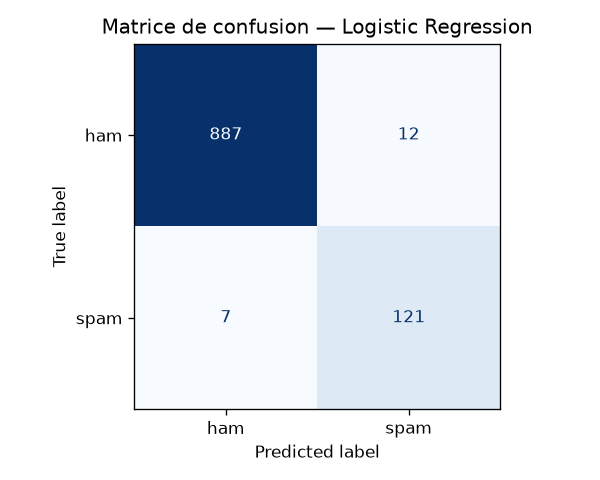

In [9]:
matrix = confusion_matrix(test['label'], predictions, labels=['ham', 'spam'])
tn, fp, fn, tp = matrix.ravel()

confusion_summary = pd.Series({
    'Vrais négatifs': int(tn),
    'Faux positifs': int(fp),
    'Faux négatifs': int(fn),
    'Vrais positifs': int(tp),
})
display(confusion_summary.to_frame('nombre'))

figure, axis = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=['ham', 'spam'],
).plot(cmap='Blues', colorbar=False, ax=axis)
axis.set_title('Matrice de confusion — Logistic Regression')
figure.tight_layout()

image_buffer = BytesIO()
figure.savefig(image_buffer, format='png', dpi=120)
plt.close(figure)
display(Image(data=image_buffer.getvalue()))

## 11. Conclusion

La Logistic Regression constitue une baseline simple et performante. Elle obtient une accuracy de **98,15 %**, une precision spam de **90,98 %**, un recall spam de **94,53 %** et un F1-score spam de **92,72 %**. Cette baseline servira de référence dans le notebook 03 pour comparer plusieurs familles d’algorithmes.